# Experiment 4: Employee Promotion Prediction using Decision Tree

**Course:** MTech AI - DTU

**Task Type:** Classification

**Model:** Decision Tree

**Problem Statement:** Predict whether an employee will be promoted based on experience, performance rating,
training score, and previous achievements.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
np.random.seed(42)


## 1. Dataset

No dataset file was provided with the assignment, so a synthetic dataset of 1000 employees is generated here.
`promoted` is drawn probabilistically from a function of the features (not a hard rule), so the labels carry
realistic noise instead of being perfectly separable.


In [2]:
n = 1000

experience = np.random.normal(8, 5, n).clip(0, 35).round(1)            # years
performance_rating = np.random.randint(1, 6, n)                        # 1 (poor) to 5 (excellent)
training_score = np.random.normal(65, 15, n).clip(30, 100).round(1)    # out of 100
previous_achievements = np.random.poisson(1.2, n).clip(0, 6)           # count of awards/certifications

logit = (
    -7
    + 0.10 * experience
    + 1.00 * performance_rating
    + 0.035 * training_score
    + 0.60 * previous_achievements
    + np.random.normal(0, 1.0, n)
)
prob_promoted = 1 / (1 + np.exp(-logit))
promoted = np.random.binomial(1, prob_promoted)

df = pd.DataFrame({
    "experience": experience,
    "performance_rating": performance_rating,
    "training_score": training_score,
    "previous_achievements": previous_achievements,
    "promoted": promoted
})

df.head()


,experience,performance_rating,training_score,previous_achievements,promoted
0,10.5,4,63.1,3,1
1,7.3,1,51.8,0,0
2,11.2,3,57.1,1,1
3,15.6,5,57.3,3,1
4,6.8,3,61.1,2,0


In [3]:
df["promoted"].value_counts(normalize=True).rename("proportion")


promoted
0    0.525
1    0.475
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis


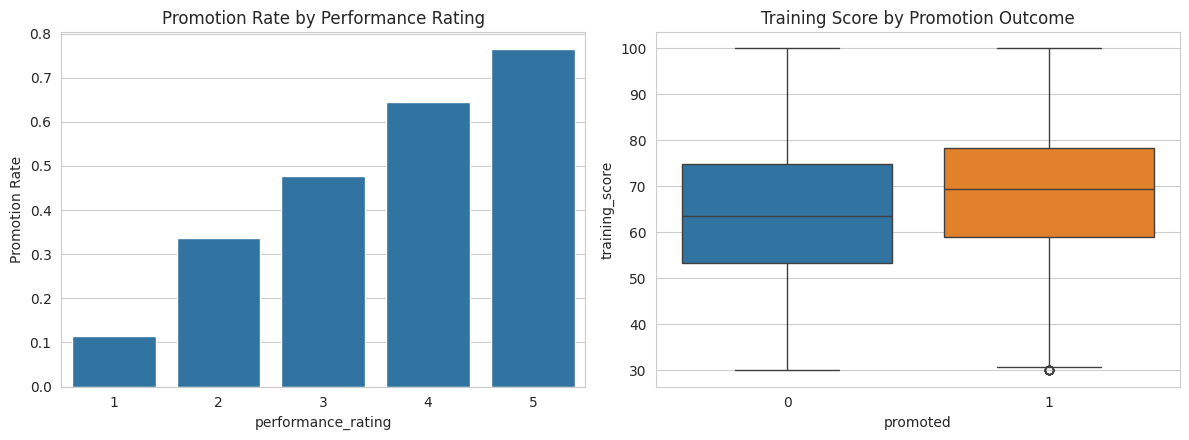

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x="performance_rating", y="promoted", data=df, ax=axes[0], errorbar=None)
axes[0].set_title("Promotion Rate by Performance Rating")
axes[0].set_ylabel("Promotion Rate")

sns.boxplot(x="promoted", y="training_score", hue="promoted", data=df, ax=axes[1], legend=False)
axes[1].set_title("Training Score by Promotion Outcome")

plt.tight_layout()
plt.show()


**Observations:**
- Promotion rate rises steadily with `performance_rating` - from roughly 1 in 10 for a rating of 1 to over 3 in 4
  for a rating of 5. This is clearly the strongest single predictor.
- Promoted employees tend to have somewhat higher training scores, but the spread between the two groups overlaps
  a fair amount - training score alone isn't decisive.


## 3. Preprocessing

All features are already numeric, and Decision Trees split on raw threshold values rather than distances, so no
scaling or encoding is needed here (unlike the KNN or Logistic Regression experiments). `stratify=y` keeps the
promoted/not-promoted ratio consistent across the train and test sets.


In [5]:
X = df.drop(columns=["promoted"])
y = df["promoted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 800
Testing samples : 200


## 4. Choosing Tree Depth

An unrestricted Decision Tree can grow until it perfectly memorizes the training data (overfitting). Train and
test accuracy are compared across a range of `max_depth` values to pick a depth that generalizes well rather than
just maximizing training accuracy.


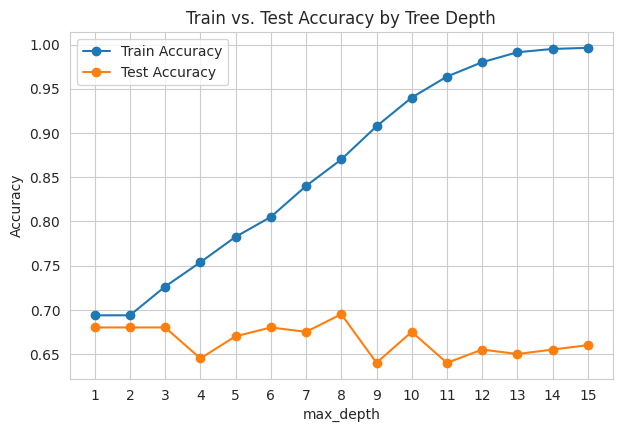

Best max_depth (by test accuracy): 8


In [6]:
depths = range(1, 16)
train_acc, test_acc = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(7, 4.5))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy")
plt.plot(depths, test_acc, marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs. Test Accuracy by Tree Depth")
plt.xticks(depths)
plt.legend()
plt.show()

best_depth = list(depths)[int(np.argmax(test_acc))]
print(f"Best max_depth (by test accuracy): {best_depth}")


As expected, training accuracy keeps climbing (and would reach 1.0 with no depth limit), while test accuracy
plateaus and can even dip once the tree starts fitting noise rather than the underlying pattern. `best_depth` is
picked from where test accuracy peaks.


## 5. Model Training - Decision Tree


In [7]:
model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not Promoted", "Promoted"]))


Test Accuracy: 0.695

              precision    recall  f1-score   support

Not Promoted       0.72      0.68      0.70       105
    Promoted       0.67      0.72      0.69        95

    accuracy                           0.69       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70      0.69      0.70       200



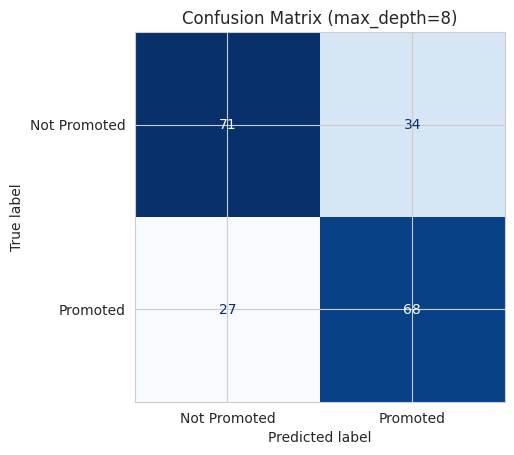

In [8]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Promoted", "Promoted"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix (max_depth={best_depth})")
plt.show()


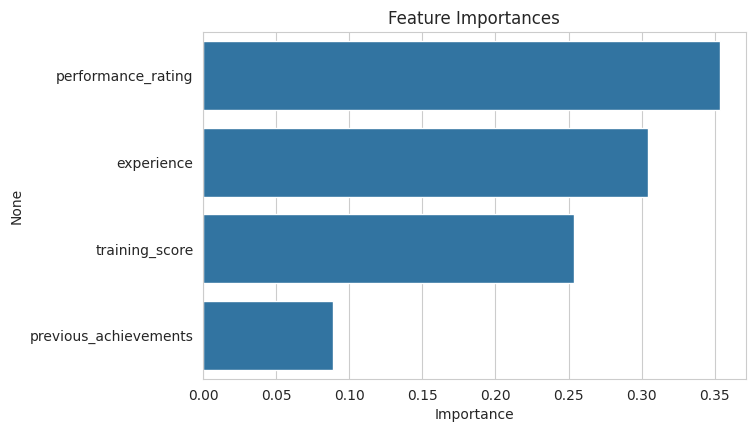

performance_rating       0.353488
experience               0.304102
training_score           0.253596
previous_achievements    0.088814
dtype: float64

In [9]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.show()

importances


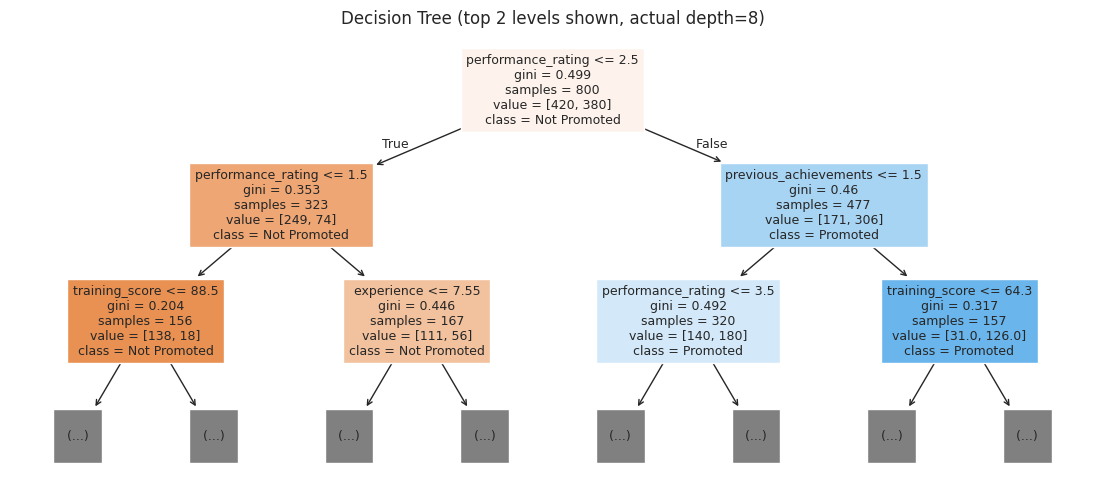

In [10]:
plt.figure(figsize=(14, 6))
plot_tree(
    model, feature_names=X.columns, class_names=["Not Promoted", "Promoted"],
    filled=True, max_depth=2, fontsize=9
)
plt.title(f"Decision Tree (top 2 levels shown, actual depth={best_depth})")
plt.show()


## 6. Conclusion

- A Decision Tree was trained to predict employee promotion from `experience`, `performance_rating`,
  `training_score`, and `previous_achievements`, after tuning `max_depth` against test accuracy to control
  overfitting.
- `performance_rating` dominates the feature importances, matching the clear trend seen in the EDA; the other
  features contribute smaller, supporting signal.
- The train-vs-test accuracy curve makes the overfitting risk of unconstrained trees concrete - a useful
  illustration for why depth (or other pruning controls) matters for this model family.
- **Possible extensions:** compare against a Random Forest to reduce the variance of a single tree, use
  cross-validation instead of a single train/test split when selecting `max_depth`, or tune `min_samples_leaf` as
  an alternative regularizer.
